In [1]:
import os
import shutil
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader   
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch.nn.functional as F

import xml.etree.ElementTree as ET
from PIL import Image, ImageFile

from pathlib import Path

from PIL import Image, ImageDraw

ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


data load 및 확인

In [2]:


ROOT = Path("~/datasets/stanfordimagenetdogs").expanduser()

ann_path = ROOT / "Annotation" / "n02085620-Chihuahua" / "n02085620_7"

tree = ET.parse(ann_path)
root = tree.getroot()

for obj in root.iter("object"):
    bbox = obj.find("bndbox")
    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    print(xmin, ymin, xmax, ymax)

71 1 192 180


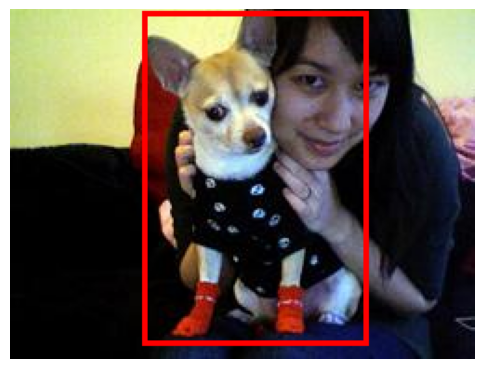

In [3]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

img_path = ROOT / "Images" / "n02085620-Chihuahua" / "n02085620_7.jpg"
ann_path = ROOT / "Annotation" / "n02085620-Chihuahua" / "n02085620_7"

img = Image.open(img_path).convert("RGB")

tree = ET.parse(ann_path)
root = tree.getroot()

draw = ImageDraw.Draw(img)

for obj in root.iter("object"):
    bbox = obj.find("bndbox")
    xmin = int(bbox.find("xmin").text)
    ymin = int(bbox.find("ymin").text)
    xmax = int(bbox.find("xmax").text)
    ymax = int(bbox.find("ymax").text)

    draw.rectangle([xmin, ymin, xmax, ymax], outline="red", width=3)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
# 원본 데이터 경로 (압축 해제 후 폴더)
images_dir = os.path.join(os.getenv("HOME"), 'datasets/stanfordimagenetdogs/Images')   # 이미지들이 위치한 폴더
mat_dir = os.path.join(os.getenv("HOME"), 'datasets/stanfordimagenetdogs')   # 프로젝트 루트 디렉토리

# .mat 파일 경로 (train_list.mat와 test_list.mat가 각각 같은 구조라고 가정)
train_mat_path = os.path.join(mat_dir, 'train_list.mat')
test_mat_path = os.path.join(mat_dir, 'test_list.mat')

# .mat 파일 로드
train_mat = sio.loadmat(train_mat_path)
test_mat = sio.loadmat(test_mat_path)

# train_mat와 test_mat 내부에 'file_list'와 'labels' 등이 있음
train_file_list = train_mat['file_list']
train_labels = train_mat['labels'].squeeze()  # (N,)
test_file_list = test_mat['file_list']
test_labels = test_mat['labels'].squeeze()

# 최종적으로 ImageFolder 구조로 재구성할 대상 폴더 생성 (예: stanford_dogs/train, stanford_dogs/test)
base_dir = 'stanford_dogs'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

def process_mat_file(file_list_array, split_dir):
    """
    .mat 파일에서 로드한 file_list_array를 사용해,
    split_dir(예: train 혹은 test)에 클래스별 폴더를 생성하고 이미지를 복사합니다.
    """
    num_files = file_list_array.shape[0]
    for idx in range(num_files):
        # file_list_array[idx]는 보통 array([<파일경로>]) 형태입니다.
        # 따라서, array([<파일경로>]).item()을 사용하면 실제 문자열을 얻을 수 있습니다.
        file_path = file_list_array[idx][0].item()

        # 혹시 bytes 타입이면 문자열로 디코딩
        if isinstance(file_path, bytes):
            file_path = file_path.decode('utf-8')

        # 파일 경로 예시: 'n02116738-African_hunting_dog/n02116738_2988.jpg'
        # 클래스 이름은 파일 경로의 최상위 폴더명 (예: 'n02116738-African_hunting_dog')
        class_folder = file_path.split('/')[0]

        # 대상 클래스 폴더 생성
        dest_folder = os.path.join(split_dir, class_folder)
        os.makedirs(dest_folder, exist_ok=True)

        # 원본 이미지 경로: Images 폴더 아래에 file_path 위치
        src_path = os.path.join(images_dir, file_path)
        # 대상 이미지 경로: dest_folder 아래에 원본 파일명 그대로 복사
        dest_path = os.path.join(dest_folder, os.path.basename(file_path))

        # 파일 존재 여부 확인 후 복사
        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)
        else:
            print(f"File not found: {src_path}")

print("Processing train set...")
process_mat_file(train_file_list, train_dir)
print("Processing test set...")
process_mat_file(test_file_list, test_dir)

print("Dataset reorganization complete.")

Processing train set...
Processing test set...
Dataset reorganization complete.


In [5]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        # bbox 기본값 (예: [xmin, ymin, xmax, ymax])
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(annot_path):
            try:
                # 확장자가 없지만 XML 형식의 파일이라고 가정하고 파싱
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                # 첫 번째 object 태그에서 bndbox 정보를 읽음
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        # XML 내 <size> 태그에서 원본 이미지 크기 획득
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        # bbox 좌표 순서: [xmin, ymin, xmax, ymax]
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
                    else:
                        print(f"bndbox 태그를 찾을 수 없습니다: {annot_path}")
                else:
                    print(f"object 태그를 찾을 수 없습니다: {annot_path}")
            except Exception as e:
                print(f"Error parsing {annot_path}: {e}")
        else:
            print(f"Annotation file not found: {annot_path}")

        return image, label, bbox

In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 데이터셋 경로 (재구성한 ImageFolder 형식)
train_dir = os.path.join('stanford_dogs', 'train')
test_dir = os.path.join('stanford_dogs', 'test')
# Annotation 폴더 경로 (예: '/root/Annotation')
annotation_dir = os.path.join(os.getenv("HOME"), 'datasets/stanfordimagenetdogs/Annotation')

# 커스텀 데이터셋 생성: image, label, bbox 반환
train_dataset = StanfordDogsDatasetWithBBox(root=train_dir, annotation_root=annotation_dir, transform=transform)
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir, annotation_root=annotation_dir, transform=transform)

batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(valid_dataset)}")

Number of classes: 120
Train samples: 12000
Test samples: 8580


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 데이터셋 경로 (재구성한 ImageFolder 형식)
train_dir = os.path.join('stanford_dogs', 'train')
test_dir = os.path.join('stanford_dogs', 'test')
# Annotation 폴더 경로 (예: '/root/Annotation')
annotation_dir = os.path.join(os.getenv("HOME"), 'datasets/stanfordimagenetdogs/Annotation')

# 커스텀 데이터셋 생성: image, label, bbox 반환
train_dataset = StanfordDogsDatasetWithBBox(root=train_dir, annotation_root=annotation_dir, transform=transform)
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir, annotation_root=annotation_dir, transform=transform)

batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(valid_dataset)}")

Number of classes: 120
Train samples: 12000
Test samples: 8580


In [8]:
def visualize(sample):
    img_tensor, label, bbox = sample

    # 인덱스와 클래스 정보
    print("Label index:", label)
    print("Class name:", train_dataset.classes[label])

    # 정규화 복원 전처리 시 사용한 평균과 표준편차
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # tensor의 shape: (C, H, W) -> (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img_np)

    # bbox 좌표는 Resize((224, 224))가 적용된 이미지 기준의 [xmin, ymin, xmax, ymax]
    xmin, ymin, xmax, ymax = bbox
    if [xmin, ymin, xmax, ymax] != [0.0, 0.0, 0.0, 0.0]:
        rect = plt.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            edgecolor="red",
            linewidth=2,
        )
        ax.add_patch(rect)

    ax.set_title(f"Class: {train_dataset.classes[label]}")
    ax.axis('off')
    plt.show()

Label index: 0
Class name: n02085620-Chihuahua


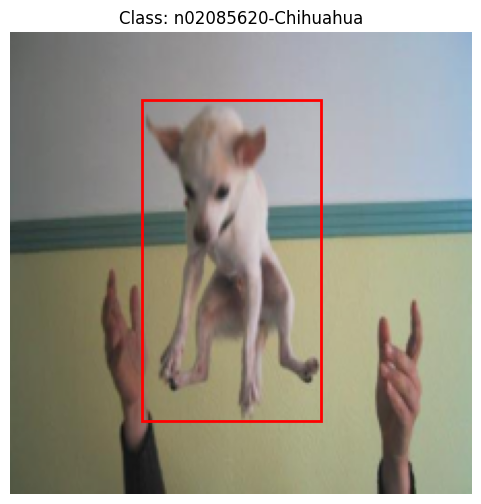

In [9]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
train_sample = train_dataset[0]

visualize(train_sample)

In [10]:
# Annotation 폴더에서 데이터를 골라보세요
annotation_path = os.path.join(os.getenv("HOME"), 'datasets/stanfordimagenetdogs/Annotation/n02085620-Chihuahua/n02085620_10074')


# XML 파일 파싱
tree = ET.parse(annotation_path)
root = tree.getroot()

for elem in root.iter():
    print(f"{elem.tag}: {elem.text}")

annotation: 
	
folder: 02085620
filename: n02085620_10074
source: 
		
database: ImageNet database
size: 
		
width: 333
height: 500
depth: 3
segment: 0
object: 
		
name: Chihuahua
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 25
ymin: 10
xmax: 276
ymax: 498


먼저 folder와 filename는 annotation와 연관된 이미지 파일의 정보를 나타냅니다. source는 해당 파일의 출처로 예시로 가져온 파일은 ImageNet에서 가져온 것으로 보입니다.  

size의 경우 원본 이미지의 크기를 나타내며 segment는 이미지가 Segmentation Mask와 연관될 경우 사용되는데 0으로 된 경우 별도의 Segmentation 정보는 없다는 것을 의미합니다.  

object에 담긴 정보는 name, pose, truncated, difficult, bndbox로 각각 다음과 같은 의미를 갖고 있습니다.  

name 객체의 클래스 이름을 나타냅니다. 여기서는 'Chihuahua'로, 해당 객체가 치와와 품종의 개임을 의미합니다.  
pose 객체의 자세(orientation)를 나타내며, 여기서는 'Unspecified'로 구체적인 자세 정보는 제공되지 않습니다.  
truncated 객체가 이미지 경계에 의해 잘려(truncated) 있는지 여부를 나타냅니다. 0은 잘리지 않았음을 의미합니다.  
difficult 객체 인식이 어려운 정도를 나타내는 플래그로, 0은 비교적 인식하기 쉬운 객체임을 의미합니다.
bndbox 객체의 위치를 사각형 영역(바운딩 박스)으로 나타내는 정보입니다.  
<xmin>25</xmin>: 바운딩 박스의 왼쪽 경계 (가로 좌표)  

<ymin>10</ymin>: 바운딩 박스의 상단 경계 (세로 좌표)  

<xmax>276</xmax>: 바운딩 박스의 오른쪽 경계 (가로 좌표)  

<ymax>498</ymax>: 바운딩 박스의 하단 경계 (세로 좌표)  

이 좌표들은 원본 이미지의 픽셀 기준 값이며, 이를 이용해 물체의 위치와 크기를 정확하게 파악할 수 있습니다.    


바운딩 박스를 라벨링하는 방법은 아주 다양합니다. 그 중 주로 사용되는 방법은 'xywh' 또는 'minmax'로 표기하는 방법입니다.  

'xywh' 는 바운딩박스 중심점을 x, y로 표기하고, 사각형의 너비 w와 높이 h를 표기하는 방법입니다.  
(예) (x_center, y_center, width, height)  
x, y가 중심점이 아니라 좌측 상단의 점을 가리킬 수도 있습니다.  
'minmax'는 바운딩박스를 이루는 좌표의 최소값과 최대값을 통해 표기하는 방법입니다.  
(예) (x_min, x_max, y_min, y_max)  
좌표의 절대값이 아니라, 전체 이미지의 너비와 높이를 기준으로 normalize한 상대적인 값을 표기하는 것이 일반적입니다.

In [11]:
from torchvision import models
from torchvision.models import ResNet50_Weights
import torch.nn as nn

num_classes = 120

weights = ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### CAM vs GRAD-CAM

In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [13]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        print(f"\nEpoch {epoch+1}/{num_epochs} 시작")
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            if (batch_idx + 1) % 50 == 0:
                print(f"  Step {batch_idx+1} - Loss: {loss.item():.4f}")

        train_loss = running_loss / (batch_idx + 1)
        train_acc = correct / total
        print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%")

        # 검증 단계
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        test_loss = running_loss / len(valid_loader)
        test_acc = correct / total
        print(f"Validation - Loss: {test_loss:.4f}, Accuracy: {test_acc*100:.2f}%")

In [14]:
%%time

train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=10)


Epoch 1/10 시작


/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


  Step 50 - Loss: 2.9077
  Step 100 - Loss: 1.2812
  Step 150 - Loss: 2.0241
  Step 200 - Loss: 2.5548
  Step 250 - Loss: 1.7160
  Step 300 - Loss: 1.4601
  Step 350 - Loss: 1.9243
  Step 400 - Loss: 2.1778
  Step 450 - Loss: 2.1012
  Step 500 - Loss: 2.0607
  Step 550 - Loss: 2.6662
  Step 600 - Loss: 1.7162
  Step 650 - Loss: 1.4056
  Step 700 - Loss: 1.8155
  Step 750 - Loss: 1.5229
  Step 800 - Loss: 0.8998
  Step 850 - Loss: 2.5108
  Step 900 - Loss: 1.5102
  Step 950 - Loss: 2.2359
  Step 1000 - Loss: 0.7875
Train - Loss: 1.8612, Accuracy: 50.04%
Validation - Loss: 1.3733, Accuracy: 60.75%

Epoch 2/10 시작
  Step 50 - Loss: 1.5962
  Step 100 - Loss: 0.9386
  Step 150 - Loss: 0.9358
  Step 200 - Loss: 0.6329
  Step 250 - Loss: 0.9775
  Step 300 - Loss: 1.3150
  Step 350 - Loss: 1.0632
  Step 400 - Loss: 1.2860
  Step 450 - Loss: 0.4939
  Step 500 - Loss: 1.3883
  Step 550 - Loss: 1.0473
  Step 600 - Loss: 1.5289
  Step 650 - Loss: 0.9541
  Step 700 - Loss: 0.9344
  Step 750 - Loss: 

In [76]:

cam_model_path = os.path.join(os.getenv("HOME"), "github/AIFFEL_quest_rs/GoingDeeper/Sp01/cam_model.pt")

torch.save(model, cam_model_path)

In [77]:
def unnormalize(img_tensor):
    """
    img_tensor: [C, H, W] 텐서 (전처리 상태, 예: normalization 적용됨)
    ImageNet 평균 및 표준편차를 이용하여 복원 (RGB 순서)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    return img

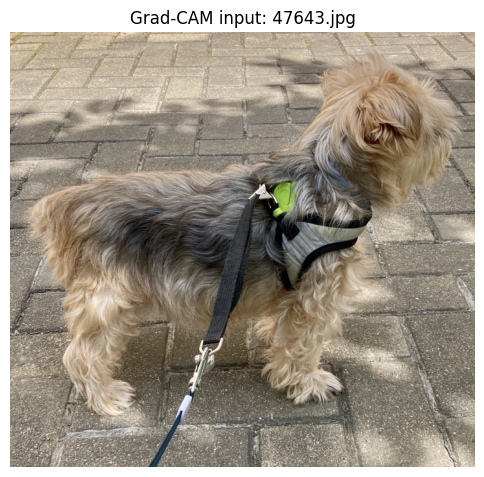

In [78]:
# Grad-CAM을 생성할 입력 이미지를 지정합니다.
gradcam_img_path = Path("/home/thkim0/github/AIFFEL_quest_rs/Exploration/Ex02/images/47643(1).jpg")

image_pil = Image.open(gradcam_img_path).convert("RGB")
image = transform(image_pil)
sample_image = image.unsqueeze(0).to(device)

plt.figure(figsize=(6, 6))
plt.imshow(image_pil)
plt.title("Grad-CAM input: 47643.jpg")
plt.axis("off")
plt.show()


In [79]:
# 모델을 불러오세요

# [[YOUR CODE]]
model = torch.load(cam_model_path, weights_only=False)

1. 특정 레이어의 출력 추출  
model.layer4에 forward hook을 등록하여, 네트워크의 feedforward 과정 중에 해당 합성곱 계층의 출력(특성 맵)을 features 리스트에 저장합니다.

2. 모델의 예측 수행 및 원하는 클래스 선택  
입력 이미지를 모델에 전달하여 feedforward를 수행하고, 출력 결과에서 배치 내 첫 번째 이미지에 대해 가장 높은 점수를 가진 클래스를 선택합니다.

3. 가중치와 특성 맵의 가중합을 통한 CAM 계산  
선택한 클래스에 해당하는 fully-connected layer의 가중치(소프트맥스 레이어의 역할을 하는 fc 레이어의 가중치)를 사용하여, 저장된 특성 맵의 각 채널과 곱셈을 수행합니다. 이렇게 채널별로 가중합을 계산하면, 해당 클래스에 기여하는 공간적 중요 영역을 반영한 CAM이 만들어집니다.

4. 정규화 및 (옵션) 리사이즈  
계산된 CAM에 ReLU를 적용하고, 최소/최대 값을 이용해 정규화합니다. 또한, 모델이 출력한 CAM의 크기는 보통 입력 이미지보다 작기 때문에, 이를 시각화하려면 입력 이미지와 동일한 크기로 리사이즈하는 것이 유용합니다. (코드에서는 리사이즈 과정은 포함되어 있지 않지만, 필요에 따라 cv2.resize 등을 사용하여 후처리할 수 있습니다.)

In [80]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [81]:
cam = generate_cam(model, sample_image)

In [82]:
def visualize_cam(cam):
    plt.imshow(cam, cmap='jet')
    plt.colorbar()
    plt.title("CAM")
    plt.axis('off')
    plt.show()

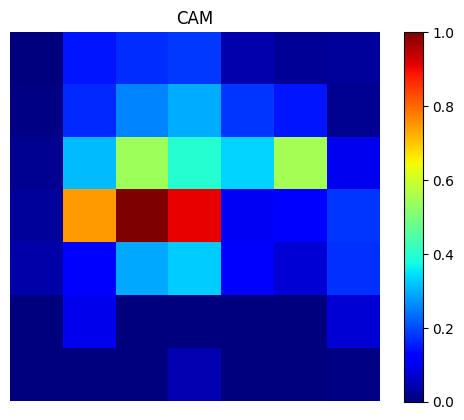

In [83]:
visualize_cam(cam)

In [92]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 크기를 원본 이미지 크기로 조정
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    # CAM을 컬러 heatmap으로 변환 (cv2.applyColorMap는 BGR로 반환하므로 RGB로 변경)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본 이미지와 heatmap을 alpha blending
    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("Grad-CAM Overlay on Image")
    plt.axis('off')
    plt.show()

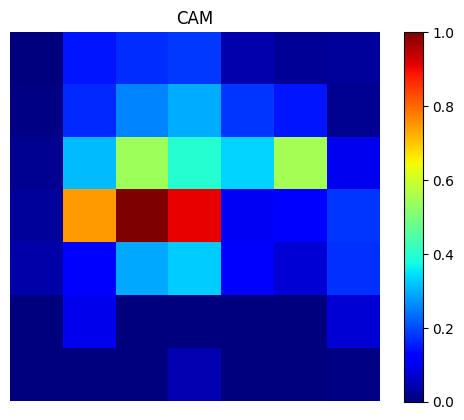

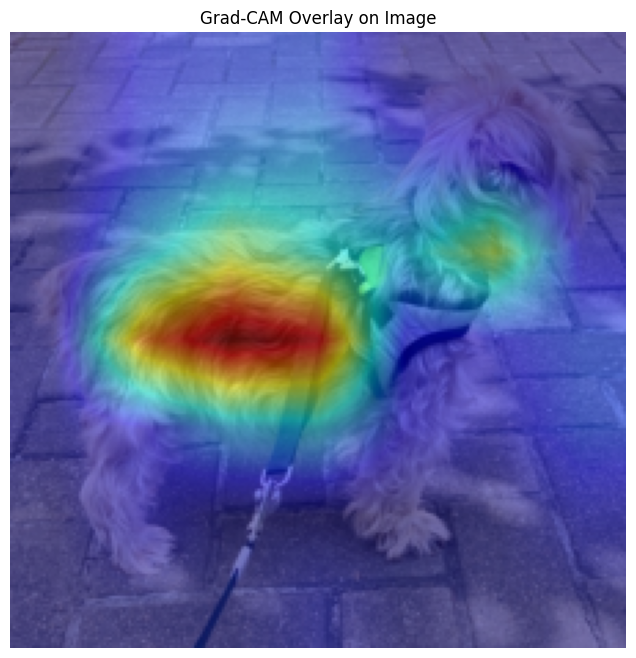

In [93]:
# 원본 이미지 복원
orig_img = unnormalize(image)

# CAM 단독 시각화
visualize_cam(cam)

# 원본 이미지 위에 CAM overlay 시각화
visualize_cam_on_image(cam, orig_img)

In [ ]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_full_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

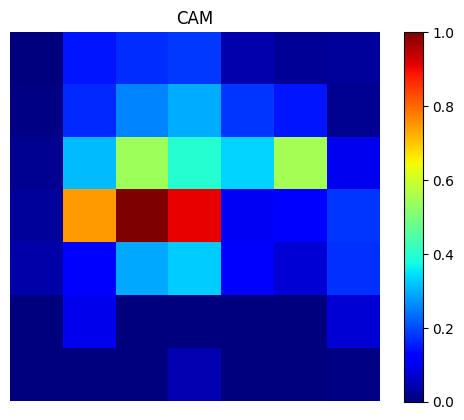

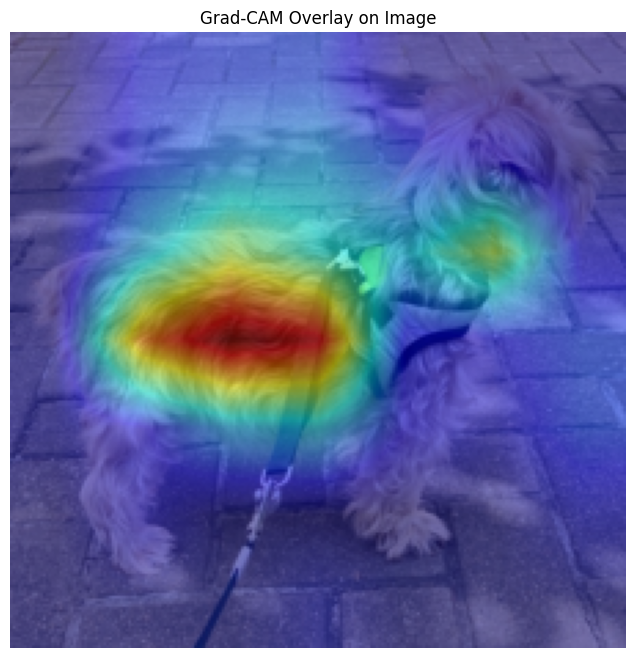

Top-3 predictions
logits shape: (1, 120)
1. class index:  50 | class name: n02097658-silky_terrier | probability: 53.18%
2. class index:  75 | class name: n02105251-briard | probability: 42.37%
3. class index:   9 | class name: n02088094-Afghan_hound | probability: 2.12%


In [95]:
# layer4 사용
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

model.eval()
with torch.no_grad():
    logits = model(sample_image)
    probs = F.softmax(logits, dim=1)
    top_probs, top_indices = torch.topk(probs[0], k=3)

print("Top-3 predictions")
print(f"logits shape: {tuple(logits.shape)}")
for rank, (prob, class_idx) in enumerate(zip(top_probs, top_indices), start=1):
    class_idx = class_idx.item()
    class_name = train_dataset.classes[class_idx]
    print(f"{rank}. class index: {class_idx:3d} | class name: {class_name} | probability: {prob.item() * 100:.2f}%")


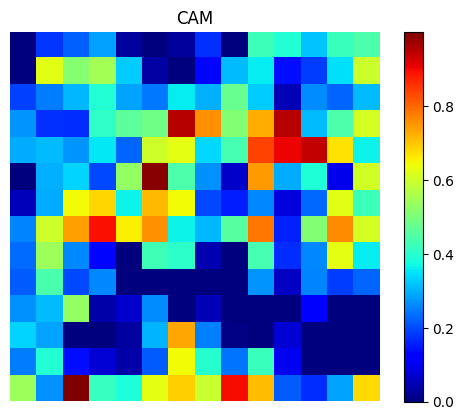

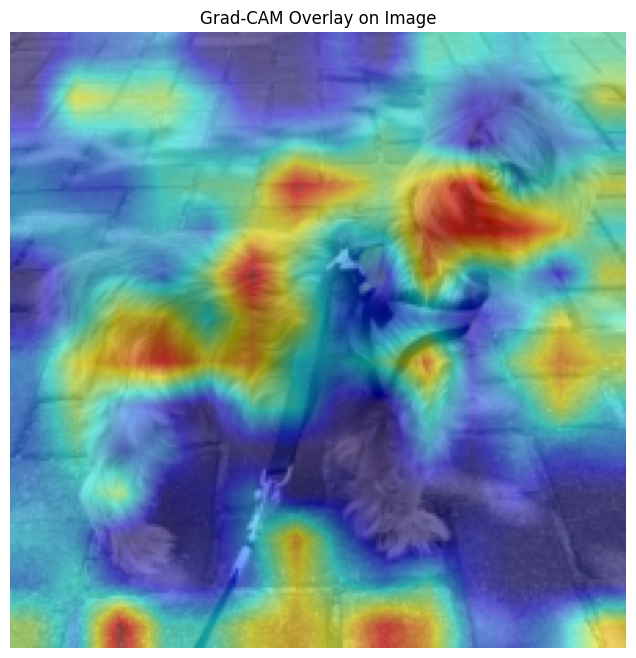

Top-3 predictions
logits shape: (1, 120)
1. class index:  50 | class name: n02097658-silky_terrier | probability: 53.18%
2. class index:  75 | class name: n02105251-briard | probability: 42.37%
3. class index:   9 | class name: n02088094-Afghan_hound | probability: 2.12%


In [96]:
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer3")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

# sample_image shape: [1, 3, 224, 224]
# 모델 내부에서는 layer4 -> avgpool -> fc(120)을 거쳐 120개 class logits이 나오고,
# softmax를 적용하면 각 class에 대한 예측 확률로 해석할 수 있습니다.
model.eval()
with torch.no_grad():
    logits = model(sample_image)
    probs = F.softmax(logits, dim=1)
    top_probs, top_indices = torch.topk(probs[0], k=3)

print("Top-3 predictions")
print(f"logits shape: {tuple(logits.shape)}")
for rank, (prob, class_idx) in enumerate(zip(top_probs, top_indices), start=1):
    class_idx = class_idx.item()
    class_name = train_dataset.classes[class_idx]
    print(f"{rank}. class index: {class_idx:3d} | class name: {class_name} | probability: {prob.item() * 100:.2f}%")
